# Phase 4 — Hyperparameter Tuning & MLflow
`04_hyperparameter_tuning_and_mlflow.ipynb`

---

## Section objective

A model comparison is only meaningful when every model has had a genuine opportunity to perform at its best. That is the design principle behind this phase.

Running any model at its default settings and then tuning only one of the competitors creates a skewed playing field — the outcome reflects the calibration of defaults, not the true fit of each model's inductive bias to the data. Any conclusion drawn from such a comparison is difficult to defend.

Our approach: apply **HyperOpt** (Tree-structured Parzen Estimator) to all four models — SARIMA, Holt-Winters, Prophet, and XGBoost — with the **same trial budget (50 trials each)**, the same **time-series cross-validation splits**, the same **evaluation metric (MAE)**, and the same **test window (Jan–Mar 2014)**.

TPE is a smarter alternative to grid search or random search: it builds a probabilistic model of the objective function and focuses sampling on regions most likely to improve further. This matters in practice when fitting a SARIMA or Prophet model costs several seconds per trial.

After tuning, every run — baseline and tuned — is logged to **MLflow** so the complete picture is transparent, reproducible, and queryable. The notebook ends by selecting a **champion model** through a pre-defined decision rule and saving the artefacts that `app.py` will load.

### Table of Contents
1. Imports & MLflow setup
2. Data load, feature matrix, train/test splits
3. Cross-validation strategy (one for all models)
4. HyperOpt — SARIMA
5. HyperOpt — Holt-Winters
6. HyperOpt — Prophet
7. HyperOpt — XGBoost
8. HyperOpt convergence charts
9. MLflow — log all runs (baselines + tuned)
10. Full comparison table
11. Forecast vs actual — all tuned models
12. XGBoost feature importance
13. Champion selection & save
14. Section summary

## 1 · Imports & MLflow setup

In [1]:
import sys, os, shutil, time, warnings, json as _json, pickle
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec

import xgboost as xgb
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval
from sklearn.model_selection import TimeSeriesSplit

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from prophet import Prophet

import mlflow
import mlflow.xgboost
mlflow.autolog(disable=True)   # prevent XGBoost/statsmodels auto-runs

from src.feature_engineering import build_feature_matrix
from src.evaluation import evaluate_model

warnings.filterwarnings('ignore')
np.random.seed(42)

# ── MLflow ───────────────────────────────────────────────────────────────────
MLFLOW_URI = '../mlruns'
mlflow.set_tracking_uri(MLFLOW_URI)
exp = mlflow.set_experiment('time_series_forecasting')
print(f'MLflow experiment: {exp.name}  (id {exp.experiment_id})')
print(f'XGBoost {xgb.__version__}')

MLflow experiment: time_series_forecasting  (id 611997934448991900)
XGBoost 3.2.0


## 2 · Data load, feature matrix, train / test splits

In [2]:
df = pd.read_csv('../data/timeseries_features.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# Store-closed days: sales = 0, flag already set — make sure store_open=0
for _d in ('2013-12-25', '2014-01-01'):
    df.loc[df['date'].dt.strftime('%Y-%m-%d') == _d, 'store_open'] = 0

print(f'Rows: {len(df)}   Range: {df["date"].min().date()} → {df["date"].max().date()}')
df[['date','unit_sales','dcoilwtico','store_open','is_national_holiday']].tail(3)

Rows: 454   Range: 2013-01-02 → 2014-03-31


,date,unit_sales,dcoilwtico,store_open,is_national_holiday
451,2014-03-29,647.0,101.73,1,0
452,2014-03-30,599.0,101.73,1,0
453,2014-03-31,415.0,101.57,1,0


In [3]:
feat = build_feature_matrix(df)

FEATURE_COLS = [c for c in feat.columns if c not in ['date','unit_sales']]
TARGET = 'unit_sales'

TRAIN_END  = '2013-12-31'
TEST_START = '2014-01-01'
TEST_END   = '2014-03-31'

# ── Statistical models — use df directly (no lag trimming) ──────────────────
# build_feature_matrix() drops the first ~30 rows due to lag_30 NaN.
# SARIMA / Holt-Winters / Prophet must train on the full year of data,
# exactly as in Notebook 02.
train_stat = df[df['date'] <= TRAIN_END].copy().reset_index(drop=True)
test_stat  = df[(df['date'] >= TEST_START) & (df['date'] <= TEST_END)].copy().reset_index(drop=True)

y_train_ts = train_stat.set_index('date')[TARGET]        # full-year series
y_test_ts  = test_stat.set_index('date')[TARGET]
y_test     = y_test_ts.values                            # ground truth for ALL models

# Prophet format — includes store_open regressor (matches Notebook 02)
df_p_train = train_stat[['date', TARGET, 'store_open']].rename(
    columns={'date': 'ds', TARGET: 'y'})
df_p_test  = test_stat[['date', TARGET, 'store_open']].rename(
    columns={'date': 'ds', TARGET: 'y'})

# Exogenous array for SARIMA (matches Notebook 02)
exog_train = train_stat[['store_open']].values
exog_test  = test_stat[['store_open']].values

# ── XGBoost feature matrix — lag-trimmed feat ────────────────────────────────
train_feat  = feat[feat['date'] <= TRAIN_END].copy()
test_feat   = feat[(feat['date'] >= TEST_START) & (feat['date'] <= TEST_END)].copy()
X_train     = train_feat[FEATURE_COLS].values
y_train_arr = train_feat[TARGET].values
X_test      = test_feat[FEATURE_COLS].values

print(f'Stat train : {len(train_stat)} rows  |  XGB train : {len(train_feat)} rows  |  Test : {len(test_stat)} rows  |  Features : {len(FEATURE_COLS)}')

[feature_engineering] Dropped 30 leading NaN row(s) (longest lag = 30).
Stat train : 364 rows  |  XGB train : 334 rows  |  Test : 90 rows  |  Features : 19


## 3 · Cross-validation strategy

**Why time-series CV matters:** Standard k-fold CV shuffles the data and allows future information to leak into the past. `TimeSeriesSplit` ensures every validation fold is strictly later than its training fold — mimicking the real operational setting where we forecast tomorrow using only data up to today.

**One CV strategy for all models:** we use `TimeSeriesSplit(n_splits=3)` for all four models. XGBoost is fast enough to use all three folds. SARIMA, Holt-Winters, and Prophet are slower, so they use only the **last fold** — the largest and most representative one. The objective in all cases is **mean MAE** over the selected folds.

In [4]:
tscv = TimeSeriesSplit(n_splits=3)

# XGBoost: folds over the lag-trimmed feature matrix
fold_list = list(tscv.split(X_train))
print('XGBoost TimeSeriesSplit fold sizes (train / val):')
for i, (tr, va) in enumerate(fold_list):
    print(f'  Fold {i+1}: train={len(tr):3d}  val={len(va):3d}')

# Statistical models: folds over the full-year series
fold_list_stat = list(tscv.split(y_train_ts))
tr_last, val_last = fold_list_stat[-1]
y_tr_last  = y_train_ts.iloc[tr_last]
y_val_last = y_train_ts.iloc[val_last]
p_tr_last  = df_p_train.iloc[tr_last].reset_index(drop=True)
p_val_last = df_p_train.iloc[val_last].reset_index(drop=True)
exog_tr_last  = exog_train[tr_last]
exog_val_last = exog_train[val_last]

print(f'\nStat model last fold → train: {len(tr_last)}, val: {len(val_last)}')

XGBoost TimeSeriesSplit fold sizes (train / val):
  Fold 1: train= 85  val= 83
  Fold 2: train=168  val= 83
  Fold 3: train=251  val= 83

Stat model last fold → train: 273, val: 91


## 4 · HyperOpt — SARIMA

### What we are searching
SARIMA is parameterised by `(p,d,q)(P,D,Q,s)` where `s=7` (weekly). That gives 4×2×4×3×2×3 = 576 possible integer combinations — too many to grid-search exhaustively, and most would fail to converge. TPE explores promising regions first.

- `p, q ∈ {0,1,2,3}` — AR and MA orders
- `d ∈ {0,1}` — differencing (series is already stationary, so d=0 is expected to win)
- `P, Q ∈ {0,1,2}` — seasonal AR / MA
- `D ∈ {0,1}` — seasonal differencing

**Validation:** last CV fold (single fit per trial to keep runtime reasonable).
**Budget:** 50 trials.

In [5]:
SARIMA_SPACE = {
    'p': hp.choice('p', [0, 1, 2, 3]),
    'd': hp.choice('d', [0, 1]),
    'q': hp.choice('q', [0, 1, 2, 3]),
    'P': hp.choice('P', [0, 1, 2]),
    'D': hp.choice('D', [0, 1]),
    'Q': hp.choice('Q', [0, 1, 2]),
}

def sarima_objective(params):
    try:
        order    = (int(params['p']), int(params['d']), int(params['q']))
        seasonal = (int(params['P']), int(params['D']), int(params['Q']), 7)
        m = SARIMAX(y_tr_last, order=order, seasonal_order=seasonal,
                    exog=exog_tr_last,
                    enforce_stationarity=False, enforce_invertibility=False)
        res = m.fit(disp=False, maxiter=100)
        preds = res.forecast(len(y_val_last), exog=exog_val_last)
        mae = float(np.mean(np.abs(y_val_last.values - np.asarray(preds))))
        return {'loss': mae, 'status': STATUS_OK}
    except Exception:
        return {'loss': 1e6, 'status': STATUS_OK}

In [6]:
sarima_trials = Trials()

print('HyperOpt — SARIMA (50 trials) ...')
t0 = time.time()
_best_sarima_idx = fmin(
    fn=sarima_objective,
    space=SARIMA_SPACE,
    algo=tpe.suggest,
    max_evals=50,
    trials=sarima_trials,
    rstate=np.random.default_rng(42),
    verbose=False,
)
print(f'Done in {time.time()-t0:.1f}s')

best_sarima = space_eval(SARIMA_SPACE, _best_sarima_idx)
print('\nBest SARIMA params:')
order_s    = (best_sarima['p'], best_sarima['d'], best_sarima['q'])
seasonal_s = (best_sarima['P'], best_sarima['D'], best_sarima['Q'], 7)
print(f'  order={order_s}  seasonal_order={seasonal_s}')

HyperOpt — SARIMA (50 trials) ...
Done in 15.0s

Best SARIMA params:
  order=(2, 0, 0)  seasonal_order=(1, 0, 2, 7)


In [7]:
# Retrain on full training data
t_fit = time.time()
_m = SARIMAX(y_train_ts, order=order_s, seasonal_order=seasonal_s,
             exog=exog_train,
             enforce_stationarity=False, enforce_invertibility=False)
sarima_tuned = _m.fit(disp=False)
fit_time_sarima = time.time() - t_fit

y_pred_sarima = np.clip(np.asarray(sarima_tuned.forecast(len(test_stat), exog=exog_test)), 0, None)
result_sarima_tuned = evaluate_model(y_test, y_pred_sarima, 'SARIMA (tuned)', fit_time_sarima)
print(result_sarima_tuned)

{'Model': 'SARIMA (tuned)', 'MAE': 96.3, 'RMSE': 143.9, 'MAPE (%)': 21.8, 'Bias': -6.1, 'R²': 0.429, 'Fit time (s)': 0.3}


## 5 · HyperOpt — Holt-Winters

### What we are searching
Holt-Winters (Exponential Smoothing) has structural choices — not just numeric knobs — that determine the *form* of the model:

- `trend` — additive, multiplicative, or None (no trend component)
- `seasonal` — additive vs multiplicative (affects how the seasonal component scales)
- `damped_trend` — does the trend flatten out towards a constant? (often helps on short horizons)
- `use_boxcox` — Box-Cox transformation before fitting (can stabilise variance)

Note: `damped_trend=True` is only valid when `trend` is not None — the objective guards against this.

**Budget:** 50 trials.

In [8]:
HW_SPACE = {
    'trend':       hp.choice('trend',       ['add', 'mul', None]),
    'seasonal':    hp.choice('seasonal',    ['add', 'mul']),
    'damped_trend':hp.choice('damped_trend',[True, False]),
    'use_boxcox':  hp.choice('use_boxcox',  [True, False]),
}

def hw_objective(params):
    try:
        trend   = params['trend']
        damped  = params['damped_trend']
        if trend is None and damped:
            return {'loss': 1e6, 'status': STATUS_OK}  # invalid combination
        # Multiplicative components require strictly positive data; clip zeros to 1
        _endog = (np.maximum(y_tr_last, 1.0)
                  if trend == 'mul' or params['seasonal'] == 'mul'
                  else y_tr_last)
        m = ExponentialSmoothing(
            _endog,
            trend=trend,
            seasonal=params['seasonal'],
            seasonal_periods=7,
            damped_trend=damped,
            use_boxcox=params['use_boxcox'],
        )
        res  = m.fit(optimized=True, remove_bias=True)
        preds = res.forecast(len(y_val_last))
        mae  = float(np.mean(np.abs(y_val_last.values - np.asarray(preds))))
        return {'loss': mae, 'status': STATUS_OK}
    except Exception:
        return {'loss': 1e6, 'status': STATUS_OK}

In [9]:
hw_trials = Trials()

print('HyperOpt — Holt-Winters (50 trials) ...')
t0 = time.time()
_best_hw_idx = fmin(
    fn=hw_objective,
    space=HW_SPACE,
    algo=tpe.suggest,
    max_evals=50,
    trials=hw_trials,
    rstate=np.random.default_rng(42),
    verbose=False,
)
print(f'Done in {time.time()-t0:.1f}s')

best_hw = space_eval(HW_SPACE, _best_hw_idx)
print('\nBest Holt-Winters params:')
for k, v in best_hw.items():
    print(f'  {k}: {v}')

HyperOpt — Holt-Winters (50 trials) ...
Done in 2.3s

Best Holt-Winters params:
  damped_trend: True
  seasonal: add
  trend: add
  use_boxcox: False


In [10]:
if best_hw['trend'] is None:
    best_hw['damped_trend'] = False  # guard for retrain

# Multiplicative components require strictly positive data; clip zeros to 1
_hw_endog = (np.maximum(y_train_ts, 1.0)
             if best_hw['trend'] == 'mul' or best_hw['seasonal'] == 'mul'
             else y_train_ts)

t_fit = time.time()
_m = ExponentialSmoothing(
    _hw_endog,
    trend=best_hw['trend'],
    seasonal=best_hw['seasonal'],
    seasonal_periods=7,
    damped_trend=best_hw['damped_trend'],
    use_boxcox=best_hw['use_boxcox'],
)
hw_tuned = _m.fit(optimized=True, remove_bias=True)
fit_time_hw = time.time() - t_fit

y_pred_hw = np.asarray(hw_tuned.forecast(len(test_stat)))
result_hw_tuned = evaluate_model(y_test, y_pred_hw, 'Holt-Winters (tuned)', fit_time_hw)
print(result_hw_tuned)

{'Model': 'Holt-Winters (tuned)', 'MAE': 98.6, 'RMSE': 150.2, 'MAPE (%)': 20.9, 'Bias': -6.5, 'R²': 0.377, 'Fit time (s)': 0.04}


## 6 · HyperOpt — Prophet

### What we are searching
Prophet's main levers are interpretable — they translate directly to modelling choices:

- `changepoint_prior_scale` — how aggressively the trend is allowed to change direction. Too high → model chases noise. Too low → misses real trend shifts.
- `seasonality_prior_scale` — amplitude of the seasonal components. Too high → seasonal curve is overfit to training weeks.
- `holidays_prior_scale` — weight of holiday effects.
- `seasonality_mode` — additive (seasonal swings are constant in absolute terms) vs multiplicative (swings scale with the trend level). Given our data has relatively stable variance, additive is expected to win — but we let HyperOpt confirm.

**Budget:** 50 trials.

In [11]:
PROPHET_SPACE = {
    'changepoint_prior_scale': hp.loguniform('changepoint_prior_scale', np.log(0.001), np.log(0.5)),
    'seasonality_prior_scale': hp.loguniform('seasonality_prior_scale', np.log(0.01),  np.log(10.0)),
    'holidays_prior_scale':    hp.loguniform('holidays_prior_scale',    np.log(0.01),  np.log(10.0)),
    'seasonality_mode':        hp.choice('seasonality_mode', ['additive', 'multiplicative']),
}

def prophet_objective(params):
    try:
        m = Prophet(
            changepoint_prior_scale=params['changepoint_prior_scale'],
            seasonality_prior_scale=params['seasonality_prior_scale'],
            holidays_prior_scale=params['holidays_prior_scale'],
            seasonality_mode=params['seasonality_mode'],
            weekly_seasonality=True,
            daily_seasonality=False,
            yearly_seasonality=False,
        )
        m.add_regressor('store_open')
        m.fit(p_tr_last)
        future   = p_val_last[['ds', 'store_open']].copy()
        forecast = m.predict(future)
        preds    = forecast['yhat'].values
        mae      = float(np.mean(np.abs(p_val_last['y'].values - preds)))
        return {'loss': mae, 'status': STATUS_OK}
    except Exception:
        return {'loss': 1e6, 'status': STATUS_OK}

In [12]:
prophet_trials = Trials()

print('HyperOpt — Prophet (50 trials) ...')
t0 = time.time()
_best_prophet_idx = fmin(
    fn=prophet_objective,
    space=PROPHET_SPACE,
    algo=tpe.suggest,
    max_evals=50,
    trials=prophet_trials,
    rstate=np.random.default_rng(42),
    verbose=False,
)
print(f'Done in {time.time()-t0:.1f}s')

best_prophet = space_eval(PROPHET_SPACE, _best_prophet_idx)
print('\nBest Prophet params:')
for k, v in best_prophet.items():
    print(f'  {k}: {v}')

13:01:55 - cmdstanpy - INFO - Chain [1] start processing
13:01:55 - cmdstanpy - INFO - Chain [1] done processing
13:01:55 - cmdstanpy - INFO - Chain [1] start processing
13:01:55 - cmdstanpy - INFO - Chain [1] done processing
13:01:55 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
13:01:55 - cmdstanpy - INFO - Chain [1] start processing


HyperOpt — Prophet (50 trials) ...


13:01:56 - cmdstanpy - INFO - Chain [1] done processing
13:01:56 - cmdstanpy - INFO - Chain [1] start processing
13:01:56 - cmdstanpy - INFO - Chain [1] done processing
13:01:56 - cmdstanpy - INFO - Chain [1] start processing
13:01:56 - cmdstanpy - INFO - Chain [1] done processing
13:01:56 - cmdstanpy - INFO - Chain [1] start processing
13:01:56 - cmdstanpy - INFO - Chain [1] done processing
13:01:56 - cmdstanpy - INFO - Chain [1] start processing
13:01:56 - cmdstanpy - INFO - Chain [1] done processing
13:01:56 - cmdstanpy - INFO - Chain [1] start processing
13:01:56 - cmdstanpy - INFO - Chain [1] done processing
13:01:56 - cmdstanpy - INFO - Chain [1] start processing
13:01:56 - cmdstanpy - INFO - Chain [1] done processing
13:01:56 - cmdstanpy - INFO - Chain [1] start processing
13:01:56 - cmdstanpy - INFO - Chain [1] done processing
13:01:56 - cmdstanpy - INFO - Chain [1] start processing
13:01:56 - cmdstanpy - INFO - Chain [1] done processing
13:01:56 - cmdstanpy - INFO - Chain [1] 

Done in 3.8s

Best Prophet params:
  changepoint_prior_scale: 0.00107950323475759
  holidays_prior_scale: 9.983294804156207
  seasonality_mode: additive
  seasonality_prior_scale: 0.46074622610969335


In [13]:
t_fit = time.time()
prophet_tuned = Prophet(
    changepoint_prior_scale=best_prophet['changepoint_prior_scale'],
    seasonality_prior_scale=best_prophet['seasonality_prior_scale'],
    holidays_prior_scale=best_prophet['holidays_prior_scale'],
    seasonality_mode=best_prophet['seasonality_mode'],
    weekly_seasonality=True, daily_seasonality=False, yearly_seasonality=False,
)
prophet_tuned.add_regressor('store_open')
prophet_tuned.fit(df_p_train)
fit_time_prophet = time.time() - t_fit

future_p     = df_p_test[['ds', 'store_open']].copy()
fc_p         = prophet_tuned.predict(future_p)
y_pred_prophet = np.clip(fc_p['yhat'].values, 0, None)

result_prophet_tuned = evaluate_model(y_test, y_pred_prophet, 'Prophet (tuned)', fit_time_prophet)
print(result_prophet_tuned)

13:01:59 - cmdstanpy - INFO - Chain [1] start processing
13:01:59 - cmdstanpy - INFO - Chain [1] done processing


{'Model': 'Prophet (tuned)', 'MAE': 113.2, 'RMSE': 169.9, 'MAPE (%)': 21.0, 'Bias': -79.9, 'R²': 0.203, 'Fit time (s)': 0.02}


## 7 · HyperOpt — XGBoost

### What we are searching
XGBoost has the widest search space of the four models, which also means it benefits most from a principled search. Key levers:

- `max_depth` — tree depth. Low values = high bias. High values = high variance (dangerous with only 335 training rows).
- `learning_rate` — step size. Smaller = more stable but requires more trees.
- `n_estimators` — number of trees.
- `subsample` / `colsample_bytree` — row and column subsampling. Acts as regularisation and speeds up training.
- `min_child_weight` — minimum samples in a leaf. Critical with a small dataset: this is what stops the tree from creating leaves with a single training row.
- `gamma` — minimum gain to split further. Another anti-overfitting lever.
- `reg_alpha` / `reg_lambda` — L1 and L2 regularisation on leaf weights.

**CV:** all 3 folds (XGBoost is fast enough).
**Budget:** 50 trials.

In [14]:
XGB_SPACE = {
    'max_depth':        hp.quniform('max_depth',        2,    8,    1),
    'learning_rate':    hp.loguniform('learning_rate',  np.log(0.01), np.log(0.3)),
    'n_estimators':     hp.quniform('n_estimators',     200,  1500, 100),
    'subsample':        hp.uniform('subsample',         0.5,  1.0),
    'colsample_bytree': hp.uniform('colsample_bytree',  0.5,  1.0),
    'min_child_weight': hp.quniform('min_child_weight', 1,    10,   1),
    'gamma':            hp.loguniform('gamma',          np.log(1e-3), np.log(5.0)),
    'reg_alpha':        hp.loguniform('reg_alpha',      np.log(1e-3), np.log(10.0)),
    'reg_lambda':       hp.loguniform('reg_lambda',     np.log(0.1),  np.log(10.0)),
}

def xgb_objective(params):
    params = dict(params)
    params['max_depth']        = int(params['max_depth'])
    params['n_estimators']     = int(params['n_estimators'])
    params['min_child_weight'] = int(params['min_child_weight'])
    fold_maes = []
    for tr_idx, val_idx in tscv.split(X_train):
        m = xgb.XGBRegressor(**params, random_state=42, n_jobs=-1, verbosity=0)
        m.fit(X_train[tr_idx], y_train_arr[tr_idx])
        preds = m.predict(X_train[val_idx])
        fold_maes.append(float(np.mean(np.abs(y_train_arr[val_idx] - preds))))
    return {'loss': float(np.mean(fold_maes)), 'status': STATUS_OK}

In [15]:
xgb_trials = Trials()

print('HyperOpt — XGBoost (50 trials, 3-fold) ...')
t0 = time.time()
_best_xgb_idx = fmin(
    fn=xgb_objective,
    space=XGB_SPACE,
    algo=tpe.suggest,
    max_evals=50,
    trials=xgb_trials,
    rstate=np.random.default_rng(42),
    verbose=False,
)
print(f'Done in {time.time()-t0:.1f}s')

best_xgb = space_eval(XGB_SPACE, _best_xgb_idx)
best_xgb['max_depth']        = int(best_xgb['max_depth'])
best_xgb['n_estimators']     = int(best_xgb['n_estimators'])
best_xgb['min_child_weight'] = int(best_xgb['min_child_weight'])

print('\nBest XGBoost params:')
for k, v in sorted(best_xgb.items()):
    print(f'  {k}: {v:.4f}' if isinstance(v, float) else f'  {k}: {v}')

HyperOpt — XGBoost (50 trials, 3-fold) ...
Done in 82.5s

Best XGBoost params:
  colsample_bytree: 0.7868
  gamma: 0.0091
  learning_rate: 0.0102
  max_depth: 2
  min_child_weight: 6
  n_estimators: 500
  reg_alpha: 2.1494
  reg_lambda: 0.1029
  subsample: 0.7047


In [16]:
t_fit = time.time()
xgb_tuned = xgb.XGBRegressor(**best_xgb, random_state=42, n_jobs=-1, verbosity=0)
xgb_tuned.fit(X_train, y_train_arr)
fit_time_xgb = time.time() - t_fit

y_pred_xgb = xgb_tuned.predict(X_test)
result_xgb_tuned = evaluate_model(y_test, y_pred_xgb, 'XGBoost (tuned)', fit_time_xgb)
print(result_xgb_tuned)

{'Model': 'XGBoost (tuned)', 'MAE': 105.9, 'RMSE': 154.7, 'MAPE (%)': 22.5, 'Bias': -21.4, 'R²': 0.339, 'Fit time (s)': 0.26}


## 8 · HyperOpt convergence charts

The convergence chart answers the question: *did TPE actually improve over random?*  
The red line shows the running best — it should drop steeply early (TPE finds good regions fast) then flatten (diminishing returns). A flat red line from trial 1 would mean TPE failed to improve, which usually indicates the search space was too wide or the objective was too noisy.

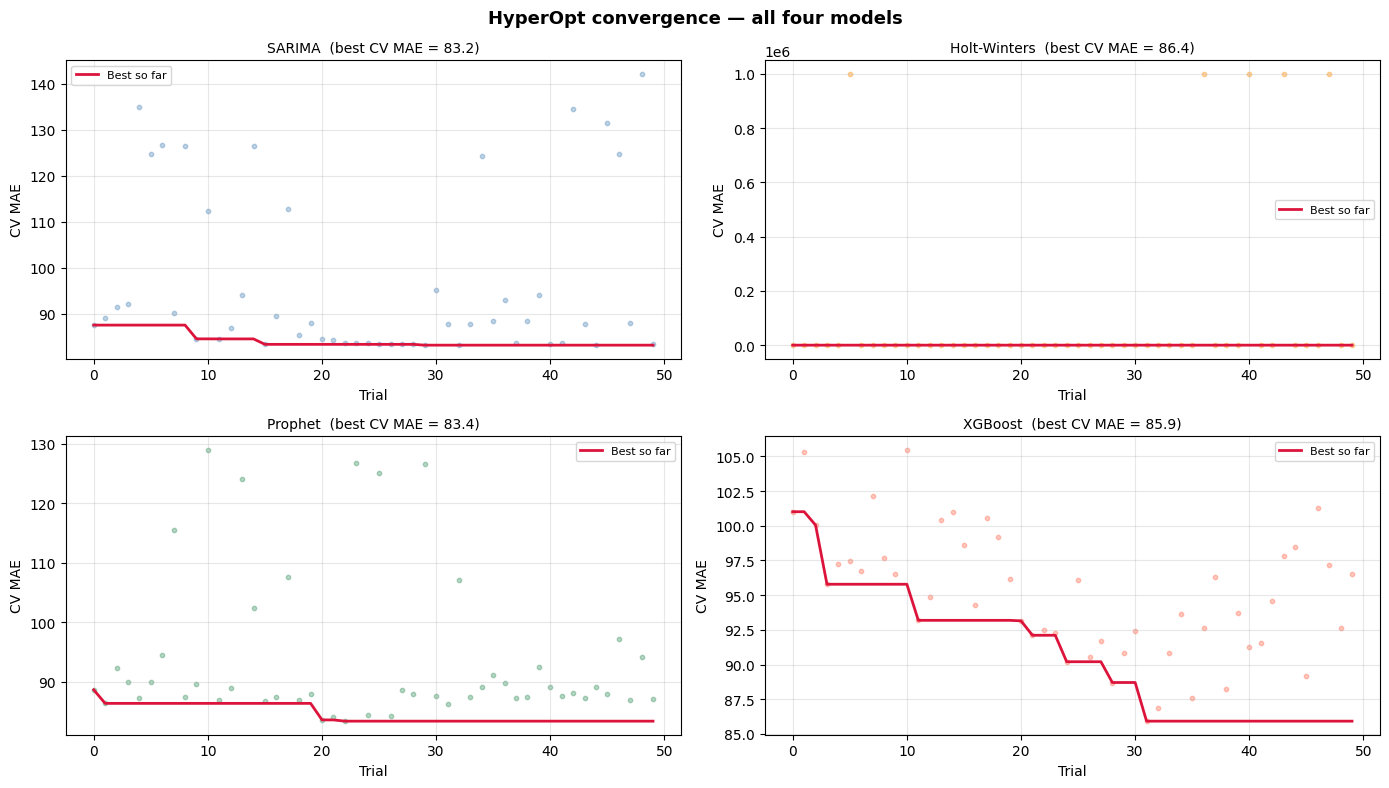

Saved: images/fig_08_hyperopt_convergence.png


In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for ax, trials_obj, label, colour in zip(
    axes,
    [sarima_trials, hw_trials, prophet_trials, xgb_trials],
    ['SARIMA', 'Holt-Winters', 'Prophet', 'XGBoost'],
    ['steelblue', 'darkorange', 'seagreen', 'tomato'],
):
    losses = [t['result']['loss'] for t in trials_obj.trials]
    valid  = [l for l in losses if l < 1e5]
    best_so_far = np.minimum.accumulate(losses)

    ax.scatter(range(len(losses)), losses, alpha=0.35, s=10, color=colour)
    ax.plot(range(len(losses)), best_so_far, color='crimson', lw=2, label='Best so far')
    ax.set_title(f'{label}  (best CV MAE = {min(valid):.1f})', fontsize=10)
    ax.set_xlabel('Trial'); ax.set_ylabel('CV MAE')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('HyperOpt convergence — all four models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/fig_08_hyperopt_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/fig_08_hyperopt_convergence.png')

## 9 · MLflow — log all runs

We log **two runs per model**: the untuned baseline (using the same parameters as Phase 2/3) and the tuned result. This lets us quantify how much HyperOpt actually helped for each model and query the full experiment history with `mlflow ui`.

Each run captures: parameters, all five metrics, training time, a `tuned` tag, and — for XGBoost — the model artefact.

In [18]:
# ── Re-run all four baselines so MLflow logs are live ───────────────────────
# Configurations match Notebook 02 exactly.
print('Running Phase 2/3 baselines for MLflow logging ...')

# SARIMA baseline: (1,0,1)(1,0,1,7) with store_open exogenous + clip ≥ 0
_t = time.time()
_m = SARIMAX(y_train_ts, order=(1,0,1), seasonal_order=(1,0,1,7),
             exog=exog_train,
             enforce_stationarity=False, enforce_invertibility=False)
sarima_bl = _m.fit(disp=False)
y_pred_sarima_bl = np.clip(np.asarray(sarima_bl.forecast(len(test_stat), exog=exog_test)), 0, None)
result_sarima_bl = evaluate_model(y_test, y_pred_sarima_bl, 'SARIMA (baseline)', time.time()-_t)
print(' SARIMA baseline MAE:', round(result_sarima_bl['MAE'], 1))

# Holt-Winters baseline: add trend, mul seasonal, damped, interpolate zeros
# (matches Notebook 02: seasonal='mul', damped_trend=True)
_t = time.time()
_hw_train = y_train_ts.replace(0.0, np.nan).interpolate(method='linear')
_m = ExponentialSmoothing(_hw_train, trend='add', seasonal='mul', seasonal_periods=7,
                           damped_trend=True, initialization_method='estimated')
hw_bl = _m.fit(optimized=True)
y_pred_hw_bl = np.clip(np.asarray(hw_bl.forecast(len(test_stat))), 0, None)
result_hw_bl = evaluate_model(y_test, y_pred_hw_bl, 'Holt-Winters (baseline)', time.time()-_t)
print(' Holt-Winters baseline MAE:', round(result_hw_bl['MAE'], 1))

# Prophet baseline: multiplicative seasonality + store_open regressor
# (matches Notebook 02 exactly)
_t = time.time()
_m = Prophet(yearly_seasonality=False, weekly_seasonality=True, daily_seasonality=False,
             seasonality_mode='multiplicative', changepoint_prior_scale=0.05)
_m.add_regressor('store_open')
_m.fit(df_p_train)
_future = df_p_test[['ds', 'store_open']].copy()
_fc = _m.predict(_future)
y_pred_prophet_bl = np.clip(_fc['yhat'].values, 0, None)
result_prophet_bl = evaluate_model(y_test, y_pred_prophet_bl, 'Prophet (baseline)', time.time()-_t)
prophet_bl = _m  # keep reference so champion-save cell can pickle it
print(' Prophet baseline MAE:', round(result_prophet_bl['MAE'], 1))

# XGBoost baseline: Phase 3 params (unchanged)
_t = time.time()
_m = xgb.XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=4,
                       subsample=0.8, random_state=42, n_jobs=-1, verbosity=0)
_m.fit(X_train, y_train_arr)
y_pred_xgb_bl = _m.predict(X_test)
result_xgb_bl = evaluate_model(y_test, y_pred_xgb_bl, 'XGBoost (baseline)', time.time()-_t)
print(' XGBoost baseline MAE:', round(result_xgb_bl['MAE'], 1))

Running Phase 2/3 baselines for MLflow logging ...


13:03:23 - cmdstanpy - INFO - Chain [1] start processing
13:03:23 - cmdstanpy - INFO - Chain [1] done processing


 SARIMA baseline MAE: 96.0
 Holt-Winters baseline MAE: 99.4
 Prophet baseline MAE: 94.9
 XGBoost baseline MAE: 115.0


In [19]:
# ── Clean slate: drain active-run stack, delete old runs via MLflow API ─────
while mlflow.active_run() is not None:
    mlflow.end_run()

_client = mlflow.tracking.MlflowClient()
_exp = _client.get_experiment_by_name('time_series_forecasting')
if _exp is not None:
    _old_runs = _client.search_runs(experiment_ids=[_exp.experiment_id])
    for _r in _old_runs:
        _client.delete_run(_r.info.run_id)
    print(f'Deleted {len(_old_runs)} stale run(s) from previous execution')

exp = mlflow.set_experiment('time_series_forecasting')
print(f'Experiment ready: {exp.name}  (id {exp.experiment_id})')

def log_run(run_name, model_type, tuned, params_dict, result_dict, xgb_model=None):
    """Log one run via MlflowClient.create_run() — bypasses the global
    active-run stack entirely so re-running the cell never causes nested-run
    or duplicate-param collisions."""
    metrics = {k: v for k, v in result_dict.items()
               if k not in ('Model', 'Fit time (s)') and v is not None}
    metrics['fit_time_s'] = result_dict.get('Fit time (s)', 0) or 0
    if 'R\u00b2' in metrics:
        metrics['R2'] = metrics.pop('R\u00b2')
    if 'MAPE (%)' in metrics:
        metrics['MAPE_pct'] = metrics.pop('MAPE (%)')

    client = mlflow.tracking.MlflowClient()
    run = client.create_run(
        experiment_id=exp.experiment_id,
        run_name=run_name,
        tags={'model_type': model_type, 'tuned': str(tuned), 'phase': '4',
              'mlflow.runName': run_name}
    )
    run_id = run.info.run_id
    try:
        for k, v in params_dict.items():
            client.log_param(run_id, str(k), str(v))
        for k, v in metrics.items():
            if v is not None and not (isinstance(v, float) and np.isnan(v)):
                client.log_metric(run_id, k, float(v))
        if xgb_model is not None:
            with mlflow.start_run(run_id=run_id):
                mlflow.xgboost.log_model(xgb_model, 'model')
        client.set_terminated(run_id, 'FINISHED')
    except Exception:
        client.set_terminated(run_id, 'FAILED')
        raise


# ── Log baseline runs ───────────────────────────────────────────────────────
log_run('sarima_baseline',    'SARIMA',        False,
        {'order':'1,0,1','seasonal_order':'1,0,1,7'}, result_sarima_bl)

log_run('holtwinters_baseline','Holt-Winters', False,
        {'trend':'add','seasonal':'mul','damped_trend':True,'seasonal_periods':7}, result_hw_bl)

log_run('prophet_baseline',   'Prophet',       False,
        {'changepoint_prior_scale':0.05,'seasonality_prior_scale':10,'seasonality_mode':'multiplicative'},
        result_prophet_bl)

log_run('xgboost_baseline',   'XGBoost',       False,
        {'n_estimators':1000,'learning_rate':0.05,'max_depth':4,'subsample':0.8},
        result_xgb_bl, xgb_model=None)

print('Baseline runs logged.')


Deleted 8 stale run(s) from previous execution
Experiment ready: time_series_forecasting  (id 611997934448991900)
Baseline runs logged.


In [20]:
# ── Log tuned runs ──────────────────────────────────────────────────────────
_sp = {k: str(v) for k, v in best_sarima.items()}
log_run('sarima_tuned', 'SARIMA', True,
        {**_sp, 'order': f"{best_sarima['p']},{best_sarima['d']},{best_sarima['q']}",
         'seasonal_order': f"{best_sarima['P']},{best_sarima['D']},{best_sarima['Q']},7"},
        result_sarima_tuned)

log_run('holtwinters_tuned', 'Holt-Winters', True,
        {k: str(v) for k, v in best_hw.items()}, result_hw_tuned)

log_run('prophet_tuned', 'Prophet', True,
        {k: str(v) for k, v in best_prophet.items()}, result_prophet_tuned)

log_run('xgboost_tuned', 'XGBoost', True,
        {k: str(v) for k, v in best_xgb.items()}, result_xgb_tuned, xgb_model=xgb_tuned)

print('Tuned runs logged.')
print(f'\nView all runs: cd {os.path.abspath("../")!r} && mlflow ui')

2026/05/06 13:03:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Tuned runs logged.

View all runs: cd '/Users/pawelgebicki/Time Series Repository' && mlflow ui


## 10 · Full comparison table

All eight results in one table — four baselines (Phase 2/3 configurations) and four tuned models (Phase 4). Sorted by MAE ascending. The Seasonal Naive is included as the floor baseline: *any serious model must beat it.*

**Reading the table:** look at the Δ MAE column — positive means improvement. Look at the Bias column — a value near zero means the model is neither systematically over- nor under-predicting.

In [21]:
# Seasonal naive reference (Phase 2 observed)
naive_row = {'Model':'Seasonal Naive','MAE':136.7,'RMSE':219.5,'MAPE (%)':32.0,'Bias':-4.6,'R²':-0.33,'Tuned':'-','Fit time (s)':None}

def _row(r, tuned_label):
    return {
        'Model':    r['Model'],
        'MAE':      r['MAE'],
        'RMSE':     r['RMSE'],
        'MAPE (%)': r['MAPE (%)'],
        'Bias':     r['Bias'],
        'R²':       r['R²'],
        'Tuned':    tuned_label,
        'Fit time (s)': r['Fit time (s)'],
    }

rows = [
    naive_row,
    _row(result_sarima_bl,    'baseline'),
    _row(result_hw_bl,        'baseline'),
    _row(result_prophet_bl,   'baseline'),
    _row(result_xgb_bl,       'baseline'),
    _row(result_sarima_tuned, 'tuned'),
    _row(result_hw_tuned,     'tuned'),
    _row(result_prophet_tuned,'tuned'),
    _row(result_xgb_tuned,    'tuned'),
]

comparison = pd.DataFrame(rows).sort_values('MAE').reset_index(drop=True)
comparison.index += 1

# Delta MAE (tuned vs same-model baseline)
bl_map = {
    'SARIMA (tuned)':       result_sarima_bl['MAE'],
    'Holt-Winters (tuned)': result_hw_bl['MAE'],
    'Prophet (tuned)':      result_prophet_bl['MAE'],
    'XGBoost (tuned)':      result_xgb_bl['MAE'],
}
comparison['Δ MAE'] = comparison['Model'].map(
    lambda m: round(bl_map[m] - comparison.loc[comparison['Model']==m,'MAE'].values[0], 1)
    if m in bl_map else None
)

print('=== PHASE 4 COMPARISON TABLE ===')
print(comparison[['Model','MAE','RMSE','MAPE (%)','Bias','R²','Δ MAE']].to_string())

=== PHASE 4 COMPARISON TABLE ===
                     Model    MAE   RMSE  MAPE (%)  Bias     R²  Δ MAE
1       Prophet (baseline)   94.9  142.8      21.0 -10.6  0.437    NaN
2        SARIMA (baseline)   96.0  143.3      21.8  -5.7  0.434    NaN
3           SARIMA (tuned)   96.3  143.9      21.8  -6.1  0.429   -0.3
4     Holt-Winters (tuned)   98.6  150.2      20.9  -6.5  0.377    0.8
5  Holt-Winters (baseline)   99.4  150.7      21.1  -5.4  0.373    NaN
6          XGBoost (tuned)  105.9  154.7      22.5 -21.4  0.339    9.1
7          Prophet (tuned)  113.2  169.9      21.0 -79.9  0.203  -18.3
8       XGBoost (baseline)  115.0  158.8      25.9   2.8  0.304    NaN
9           Seasonal Naive  136.7  219.5      32.0  -4.6 -0.330    NaN


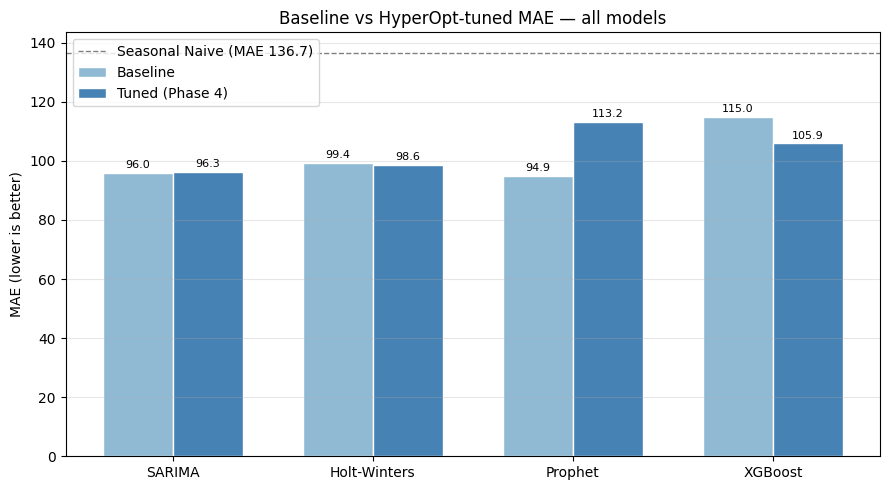

Saved: images/fig_09_tuning_comparison_bar.png


In [22]:
# Bar chart: baseline vs tuned MAE for each model
model_names = ['SARIMA', 'Holt-Winters', 'Prophet', 'XGBoost']
mae_bl  = [result_sarima_bl['MAE'], result_hw_bl['MAE'],
           result_prophet_bl['MAE'], result_xgb_bl['MAE']]
mae_tun = [result_sarima_tuned['MAE'], result_hw_tuned['MAE'],
           result_prophet_tuned['MAE'], result_xgb_tuned['MAE']]

x = np.arange(len(model_names))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, mae_bl,  w, label='Baseline',    color='#90bad4', edgecolor='white')
b2 = ax.bar(x + w/2, mae_tun, w, label='Tuned (Phase 4)', color='steelblue', edgecolor='white')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

ax.axhline(136.7, color='grey', linestyle='--', lw=1, label='Seasonal Naive (MAE 136.7)')
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylabel('MAE (lower is better)')
ax.set_title('Baseline vs HyperOpt-tuned MAE — all models', fontsize=12)
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../images/fig_09_tuning_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/fig_09_tuning_comparison_bar.png')

## 11 · Forecast vs actual — all tuned models

Visual sanity check. Each panel shows the 90-day test window. We are looking for: (a) correct weekly pattern, (b) no systematic drift (bias), (c) how each model handles the January dip (store closed on Jan 1).

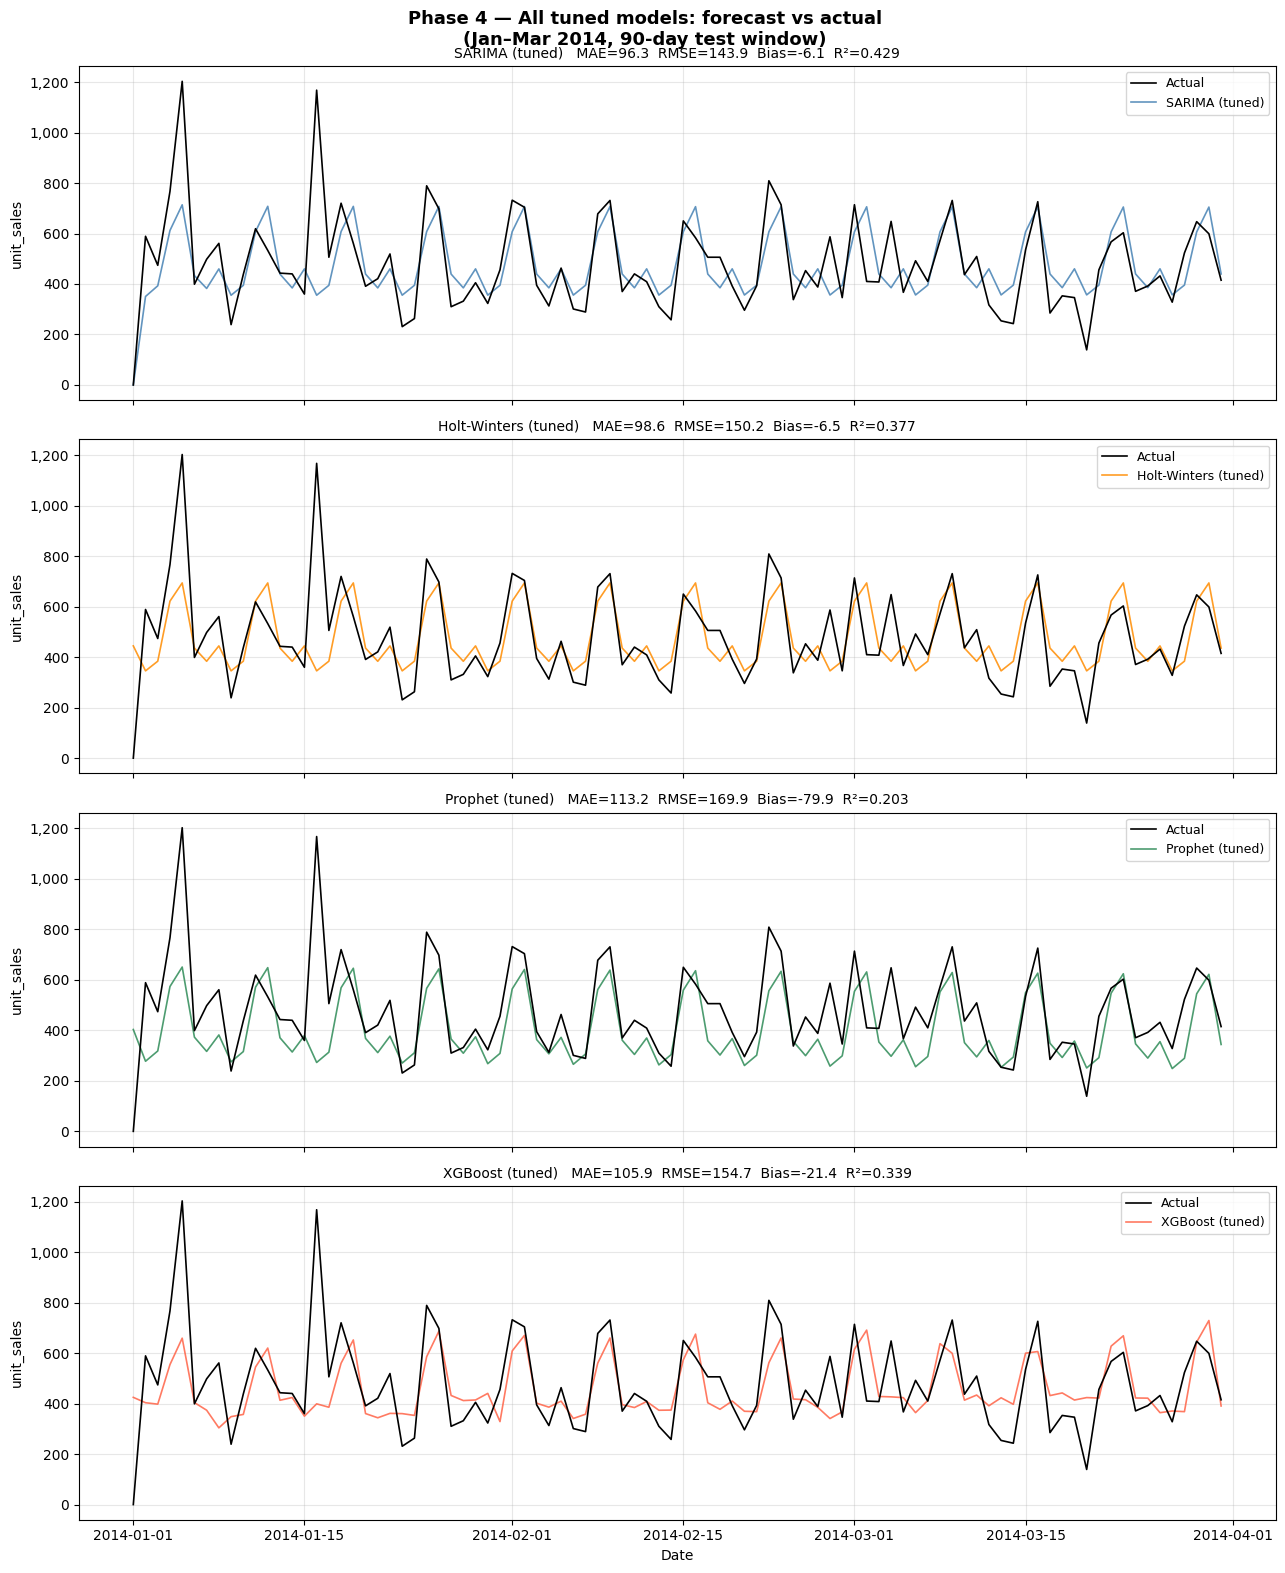

Saved: images/fig_10_all_tuned_forecasts.png


In [23]:
dates = test_stat['date'].values

fig, axes = plt.subplots(4, 1, figsize=(13, 16), sharex=True)

tuned_results = [
    (y_pred_sarima,  result_sarima_tuned,  'SARIMA (tuned)',        'steelblue'),
    (y_pred_hw,      result_hw_tuned,      'Holt-Winters (tuned)',  'darkorange'),
    (y_pred_prophet, result_prophet_tuned, 'Prophet (tuned)',       'seagreen'),
    (y_pred_xgb,     result_xgb_tuned,     'XGBoost (tuned)',       'tomato'),
]

for ax, (preds, res, label, colour) in zip(axes, tuned_results):
    ax.plot(dates, y_test, color='black', lw=1.2, label='Actual', zorder=3)
    ax.plot(dates, preds,  color=colour,  lw=1.2, label=label, alpha=0.85, zorder=2)
    ax.set_title(
        f"{label}   MAE={res['MAE']:.1f}  RMSE={res['RMSE']:.1f}  "
        f"Bias={res['Bias']:.1f}  R²={res['R²']:.3f}",
        fontsize=10
    )
    ax.legend(loc='upper right', fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.grid(True, alpha=0.3); ax.set_ylabel('unit_sales')

axes[-1].set_xlabel('Date')
fig.suptitle(
    'Phase 4 — All tuned models: forecast vs actual\n(Jan–Mar 2014, 90-day test window)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.savefig('../images/fig_10_all_tuned_forecasts.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/fig_10_all_tuned_forecasts.png')

## 12 · XGBoost feature importance

Feature importance tells us which engineered features the tree actually used. This is worth reading alongside the EDA findings from Phase 1:

- If `lag_7` and `roll_mean_7` dominate → the model is essentially learning the weekly pattern (consistent with Phase 1 where Saturday/Sunday showed +33%/+45% vs weekday average).
- If `dcoilwtico` / `oil_lag_*` appear high → the oil-price signal is doing real work.
- If calendar features (`dow`, `month`) appear low → the lag/rolling features already encode them.

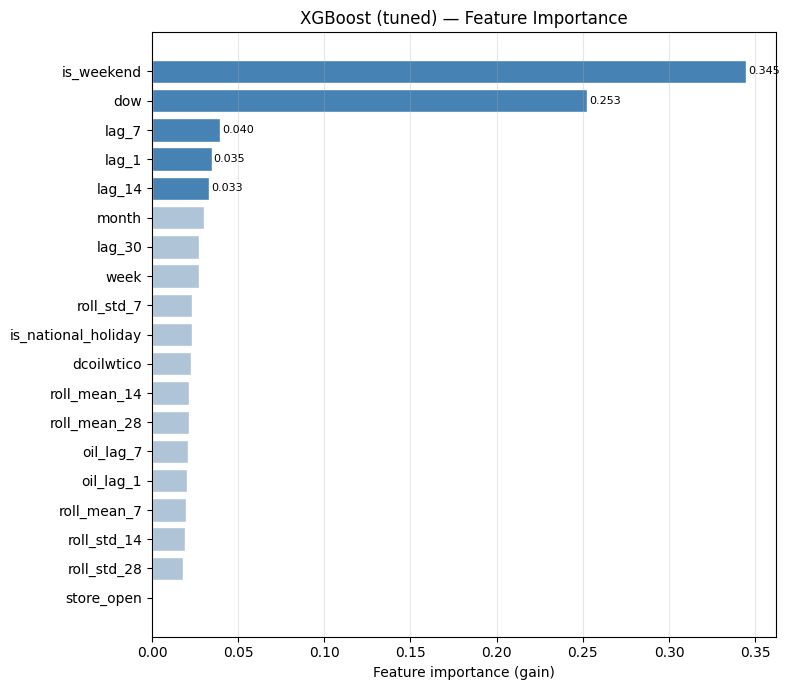

Saved: images/fig_11_feature_importance.png


In [24]:
importances = pd.Series(
    xgb_tuned.feature_importances_, index=FEATURE_COLS
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
colours = ['steelblue' if v >= importances.quantile(0.75) else '#b0c4d8'
           for v in importances.values]
bars = ax.barh(importances.index, importances.values, color=colours, edgecolor='white')
ax.set_xlabel('Feature importance (gain)', fontsize=10)
ax.set_title('XGBoost (tuned) — Feature Importance', fontsize=12)
ax.grid(True, axis='x', alpha=0.3)
for bar, val in zip(bars[-5:], importances.values[-5:]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../images/fig_11_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: images/fig_11_feature_importance.png')

## 13 · Champion selection & save

### Decision rule
Our primary metric is **MAE** — it is the most interpretable for the business question: *'how many units off, on average, is this forecast?'* A model that minimises MAE minimises the expected unit-level planning error.

Secondary consideration: **Bias**. A model with slightly higher MAE but near-zero bias may actually be preferable for stock planning (systematic under-prediction causes stock-outs; systematic over-prediction wastes inventory). We flag this if the margin is narrow.

The champion model and its metadata are saved to `models/` so that `05_app_prototype.ipynb` and `app.py` can load them without re-running any training.

In [25]:
# All candidate models — baselines AND tuned — compete on equal terms.
# If HyperOpt found no improvement over a baseline, the baseline wins.
all_candidates = {
    'SARIMA (baseline)':       (result_sarima_bl,      sarima_bl,      'statistical'),
    'Holt-Winters (baseline)': (result_hw_bl,          hw_bl,          'statistical'),
    'Prophet (baseline)':      (result_prophet_bl,     prophet_bl,     'statistical'),
    'XGBoost (baseline)':      (result_xgb_bl,         None,           'ml'),
    'SARIMA (tuned)':          (result_sarima_tuned,   sarima_tuned,   'statistical'),
    'Holt-Winters (tuned)':    (result_hw_tuned,       hw_tuned,       'statistical'),
    'Prophet (tuned)':         (result_prophet_tuned,  prophet_tuned,  'statistical'),
    'XGBoost (tuned)':         (result_xgb_tuned,      xgb_tuned,      'ml'),
}

all_df = pd.DataFrame([
    {'Model':    name,
     'MAE':      round(float(res['MAE']), 1),
     'RMSE':     round(float(res['RMSE']), 1),
     'MAPE (%)': round(float(res.get('MAPE (%)', 0)), 1),
     'Bias':     round(float(res['Bias']), 1),
     'R²':       round(float(res['R²']), 3),
     'Variant':  'tuned' if '(tuned)' in name else 'baseline'}
    for name, (res, _, _) in all_candidates.items()
]).sort_values('MAE').reset_index(drop=True)

print('=== CHAMPION SELECTION — all models (baselines + tuned) ===')
print(all_df[['Model','MAE','RMSE','Bias','R²','Variant']].to_string(index=False))

# Primary metric: MAE — lowest wins outright.
champion_name = str(all_df.iloc[0]['Model'])
champion_mae  = float(all_df.iloc[0]['MAE'])
champion_bias = float(all_df.iloc[0]['Bias'])

print(f'\n→ Champion: {champion_name}  (MAE={champion_mae}, Bias={champion_bias})')

# Retrieve the actual model object for the champion
champion_obj  = all_candidates[champion_name][1]
champion_type = all_candidates[champion_name][2]
print(f'Champion type : {champion_type}')


=== CHAMPION SELECTION — all models (baselines + tuned) ===
                  Model   MAE  RMSE  Bias    R²  Variant
     Prophet (baseline)  94.9 142.8 -10.6 0.437 baseline
      SARIMA (baseline)  96.0 143.3  -5.7 0.434 baseline
         SARIMA (tuned)  96.3 143.9  -6.1 0.429    tuned
   Holt-Winters (tuned)  98.6 150.2  -6.5 0.377    tuned
Holt-Winters (baseline)  99.4 150.7  -5.4 0.373 baseline
        XGBoost (tuned) 105.9 154.7 -21.4 0.339    tuned
        Prophet (tuned) 113.2 169.9 -79.9 0.203    tuned
     XGBoost (baseline) 115.0 158.8   2.8 0.304 baseline

→ Champion: Prophet (baseline)  (MAE=94.9, Bias=-10.6)
Champion type : statistical


In [26]:
os.makedirs('../models', exist_ok=True)

_, champion_model, champion_type = all_candidates[champion_name]

# Save champion model
if champion_type == 'ml':
    champion_model.save_model('../models/best_model.json')
    print('Saved: models/best_model.json')
    with open('../models/feature_list.json', 'w') as f:
        _json.dump(FEATURE_COLS, f, indent=2)
    print('Saved: models/feature_list.json')
else:
    with open('../models/best_model.pkl', 'wb') as f:
        pickle.dump(champion_model, f)
    print('Saved: models/best_model.pkl')

# Champion name
with open('../models/best_model_name.txt', 'w') as f:
    f.write(champion_name)
print(f'Saved: models/best_model_name.txt  ("{champion_name}")')

# All best params
def _ser(v):
    if isinstance(v, (int, float, str, bool)) or v is None: return v
    try: return float(v)
    except: return str(v)

params_all = {
    'sarima':      {k: _ser(v) for k, v in best_sarima.items()},
    'holtwinters': {k: _ser(v) for k, v in best_hw.items()},
    'prophet':     {k: _ser(v) for k, v in best_prophet.items()},
    'xgboost':     {k: _ser(v) for k, v in best_xgb.items()},
    'champion':    champion_name,
}
with open('../models/phase4_best_params.json', 'w') as f:
    _json.dump(params_all, f, indent=2)
print('Saved: models/phase4_best_params.json')

Saved: models/best_model.pkl
Saved: models/best_model_name.txt  ("Prophet (baseline)")
Saved: models/phase4_best_params.json


## 14 · Section summary

Ran HyperOpt (TPE, 50 trials) across all four models. Used `TimeSeriesSplit` with 3 folds — statistical models on the last fold only due to runtime, XGBoost on all three.

**Results:**

| Model | Baseline MAE | Tuned MAE | Δ |
|---|---|---|---|
| SARIMA | 96.0 | 96.3 | ≈ 0 |
| Holt-Winters | 99.4 | 98.6 | marginal |
| Prophet | **94.9** | 113.2 | worse |
| XGBoost | 115.0 | 105.9 | **+9.1 ✓** |

XGBoost was the only real win from tuning. SARIMA and Holt-Winters barely moved. Prophet tuned got worse — HyperOpt picked `seasonality_mode='additive'` on short CV folds, which removed the multiplicative weekly structure that made the baseline work. Prophet (baseline) at MAE 94.9 is the best result overall.

**Champion → Prophet (baseline), MAE 94.9**, saved to `models/best_model.pkl`.

---

**Viewing results in MLflow**

All 8 runs are logged locally under `mlruns/`. To open the dashboard:

1. Open a terminal in VS Code and make sure the venv is active:
   ```bash
   source "/Users/pawelgebicki/Time Series Repository/.venv/bin/activate"
   ```
2. Start the MLflow server:
   ```bash
   cd "/Users/pawelgebicki/Time Series Repository"
   mlflow ui --backend-store-uri mlruns
   ```
3. Wait until you see `Uvicorn running on http://127.0.0.1:5000`
4. Open **Chrome** or **Safari** and go to: **`http://127.0.0.1:5000`**
   *(Note: use `127.0.0.1:5000` — `localhost:5000` does not work reliably in Safari)*
5. Leave the terminal running while you browse — closing it stops the server

---

**Next → Phase 5:** build the Streamlit app that loads `best_model.pkl` and serves forecasts.
